# EDA: Voluntas MWQ Proxy

This notebook explores a proxy for the Voluntas Meaningful Work Quotient (MWQ) using available Glassdoor columns.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_PATH = Path('src/data/processed/culture_intelligence_v1.parquet')
df = pd.read_parquet(DATA_PATH)
df.head()


,firm,date_review,job_title,current,location,overall_rating,work_life_balance,culture_values,diversity_inclusion,career_opp,...,leadership,belonging,growth,mwq_proxy,pros_length,cons_length,engagement_signal,pros_sentiment,cons_sentiment,net_sentiment
0,AFH-Wealth-Management,2015-04-05,,Current Employee,NaN,2,4.0,3.0,NaN,2.0,...,3.0,4.0,2.0,3.0,59,47,12,0.8610,-0.7351,1.5961
1,AFH-Wealth-Management,2015-12-11,Office Administrator,"Current Employee, more than 1 year","Bromsgrove, England, England",2,3.0,1.0,NaN,2.0,...,4.0,3.0,2.0,2.5,45,122,-77,0.7184,-0.8663,1.5847
2,AFH-Wealth-Management,2016-01-28,Office Administrator,"Current Employee, less than 1 year","Bromsgrove, England, England",1,1.0,1.0,NaN,1.0,...,1.0,1.0,1.0,1.0,54,224,-170,0.4404,0.1709,0.2695
3,AFH-Wealth-Management,2016-04-16,,Current Employee,NaN,5,2.0,3.0,NaN,2.0,...,3.0,2.0,2.0,2.5,23,40,-17,0.4215,-0.6486,1.0701
4,AFH-Wealth-Management,2016-04-23,Office Administrator,"Current Employee, more than 1 year","Bromsgrove, England, England",1,2.0,1.0,NaN,2.0,...,1.0,2.0,2.0,1.5,37,222,-185,0.6908,-0.7861,1.4769


## MWQ Proxy Mapping
- Purpose: culture_values
- Leadership: senior_mgmt
- Belonging: mean(work_life_balance, diversity_inclusion)
- Growth: career_opp


In [2]:
mwq = df.copy()
mwq['purpose'] = mwq['culture_values']
mwq['leadership'] = mwq['senior_mgmt']
mwq['belonging'] = mwq[['work_life_balance', 'diversity_inclusion']].mean(axis=1, skipna=True)
mwq['growth'] = mwq['career_opp']

mwq['mwq_proxy'] = mwq[['purpose', 'leadership', 'belonging', 'growth']].mean(axis=1, skipna=True)
mwq[['purpose','leadership','belonging','growth','mwq_proxy']].describe()


,purpose,leadership,belonging,growth,mwq_proxy
count,838566.000000,682690.000000,689383.000000,838566.000000,838566.000000
mean,3.683695,3.176576,3.425156,3.556488,3.522148
std,1.175174,1.330720,1.268195,1.172131,0.999647
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.000000,2.000000,3.000000,3.000000,3.000000
50%,4.000000,3.000000,4.000000,4.000000,3.750000
75%,5.000000,4.000000,4.500000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000


## Correlation with Overall Rating
Check whether the MWQ proxy tracks overall_rating.

In [3]:
mwq[['mwq_proxy','overall_rating']].corr()


,mwq_proxy,overall_rating
mwq_proxy,1.000000,0.769017
overall_rating,0.769017,1.000000


## Distribution Check
Simple histograms for the proxy and drivers.

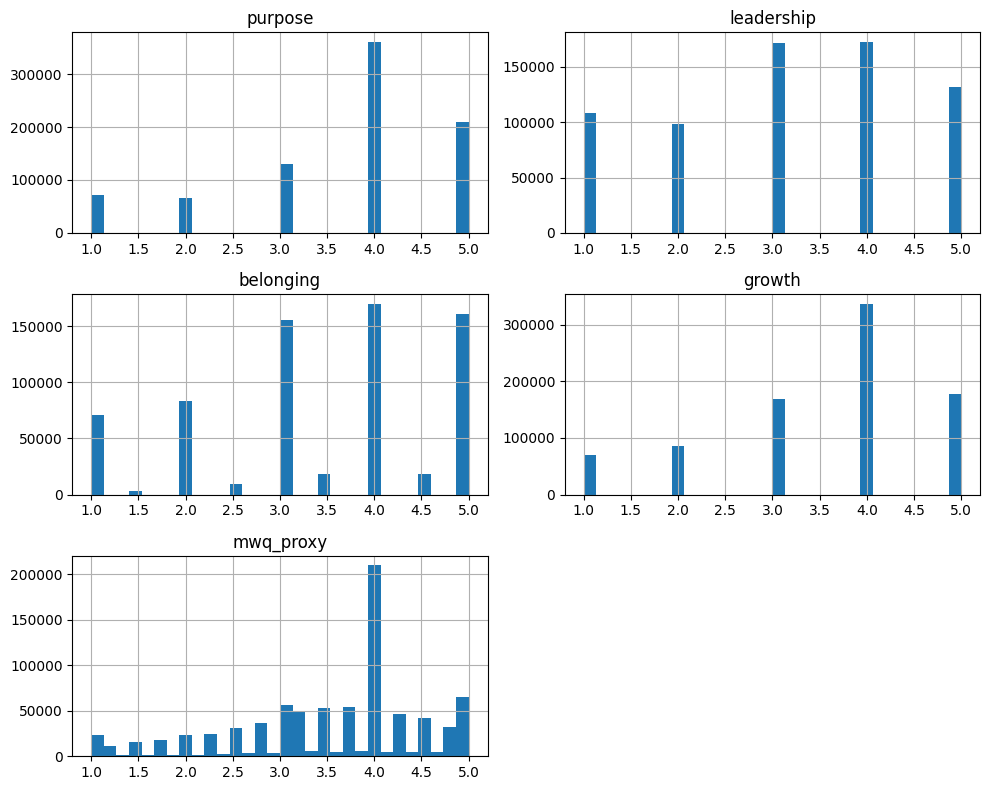

In [4]:
import matplotlib.pyplot as plt
cols = ['purpose','leadership','belonging','growth','mwq_proxy']
mwq[cols].hist(bins=30, figsize=(10,8))
plt.tight_layout()


## Next Steps
- Decide weighting (equal vs data‑driven)
- Compare with existing mwq_proxy
- Add sentiment or text features if supported by EDA

## Extended EDA Findings
This section summarizes missingness, correlations, trends over time, and firm-level patterns.

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')


### Missingness Heat (Top 12 Columns)

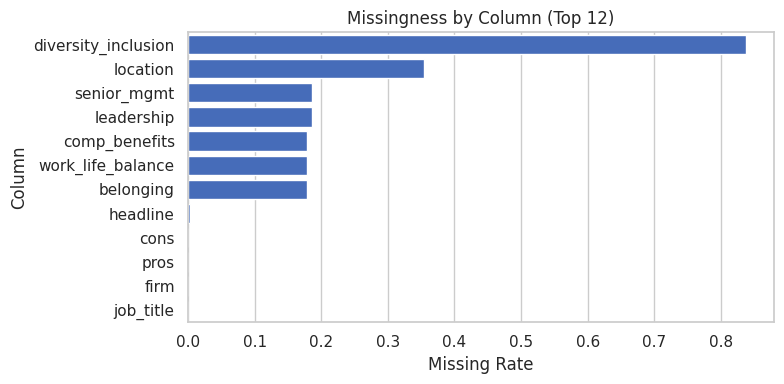

In [6]:
missing = df.isna().mean().sort_values(ascending=False)
top_missing = missing.head(12)
plt.figure(figsize=(8,4))
sns.barplot(x=top_missing.values, y=top_missing.index, color='#3366CC')
plt.title('Missingness by Column (Top 12)')
plt.xlabel('Missing Rate')
plt.ylabel('Column')
plt.tight_layout()


### Correlation with Overall Rating (Top 10)

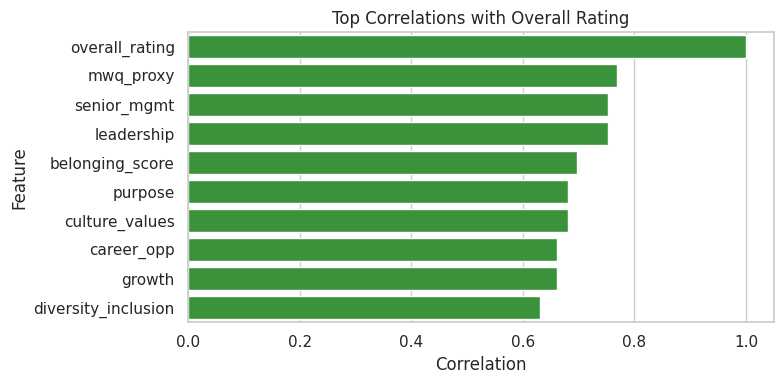

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()['overall_rating'].sort_values(ascending=False).head(10)
plt.figure(figsize=(8,4))
sns.barplot(x=corr.values, y=corr.index, color='#2CA02C')
plt.title('Top Correlations with Overall Rating')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.tight_layout()


### MWQ Proxy Trend Over Time

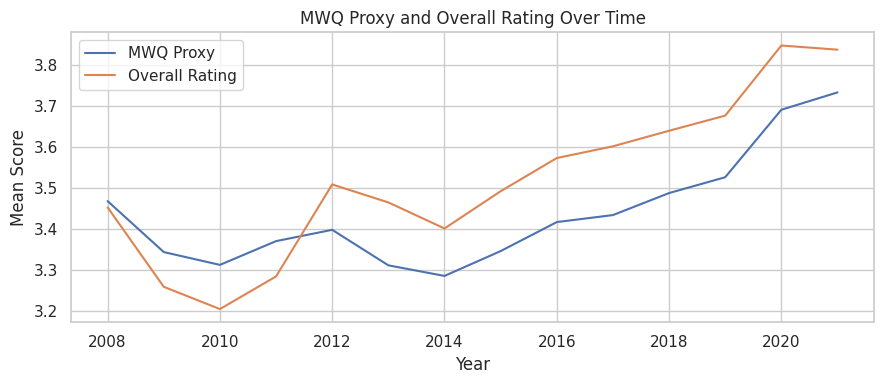

In [8]:
df['year'] = pd.to_datetime(df['date_review'], errors='coerce').dt.year
by_year = df.groupby('year')[['mwq_proxy','overall_rating']].mean().dropna()
plt.figure(figsize=(9,4))
plt.plot(by_year.index, by_year['mwq_proxy'], label='MWQ Proxy')
plt.plot(by_year.index, by_year['overall_rating'], label='Overall Rating')
plt.title('MWQ Proxy and Overall Rating Over Time')
plt.xlabel('Year')
plt.ylabel('Mean Score')
plt.legend()
plt.tight_layout()


### Firm-Level MWQ Proxy (Top vs Bottom)

/tmp/ipykernel_27125/3744378585.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  firm_scores = df[df['firm'].isin(eligible)].groupby('firm')['mwq_proxy'].mean()


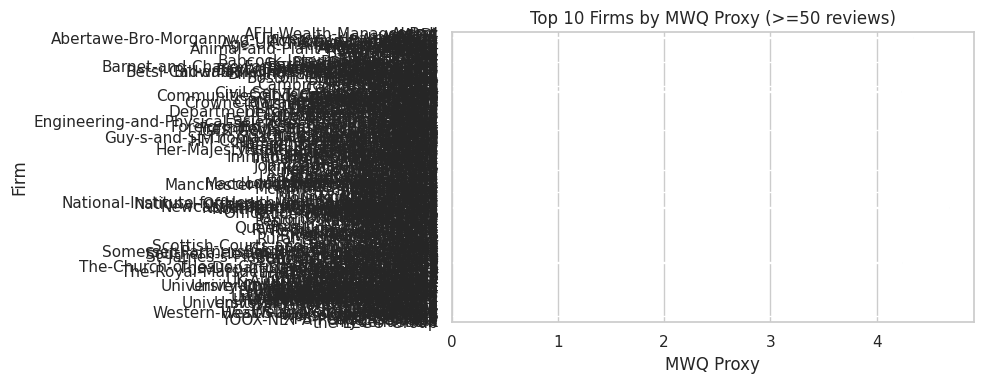

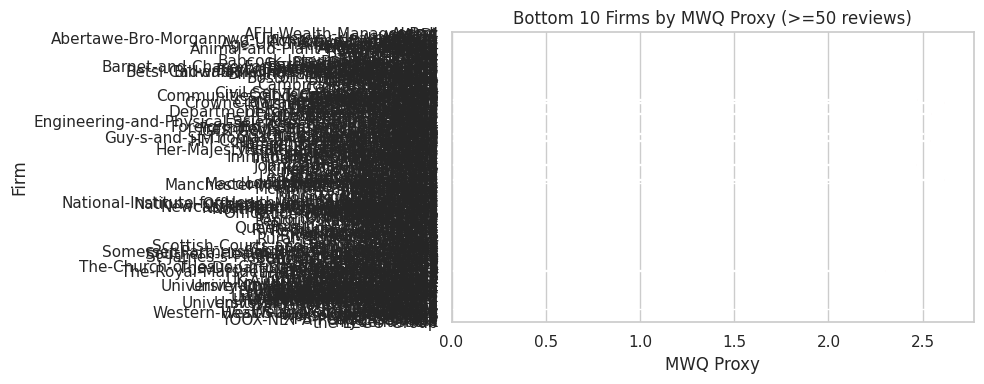

In [9]:
counts = df['firm'].value_counts()
eligible = counts[counts >= 50].index
firm_scores = df[df['firm'].isin(eligible)].groupby('firm')['mwq_proxy'].mean()
top = firm_scores.sort_values(ascending=False).head(10)
bottom = firm_scores.sort_values(ascending=True).head(10)
plt.figure(figsize=(10,4))
sns.barplot(x=top.values, y=top.index, color='#1F77B4')
plt.title('Top 10 Firms by MWQ Proxy (>=50 reviews)')
plt.xlabel('MWQ Proxy')
plt.ylabel('Firm')
plt.tight_layout()
plt.figure(figsize=(10,4))
sns.barplot(x=bottom.values, y=bottom.index, color='#D62728')
plt.title('Bottom 10 Firms by MWQ Proxy (>=50 reviews)')
plt.xlabel('MWQ Proxy')
plt.ylabel('Firm')
plt.tight_layout()


### Missingness Bias Check (culture_values)

culture_values_imputed
False    3.638882
True     3.713695
Name: overall_rating, dtype: float64

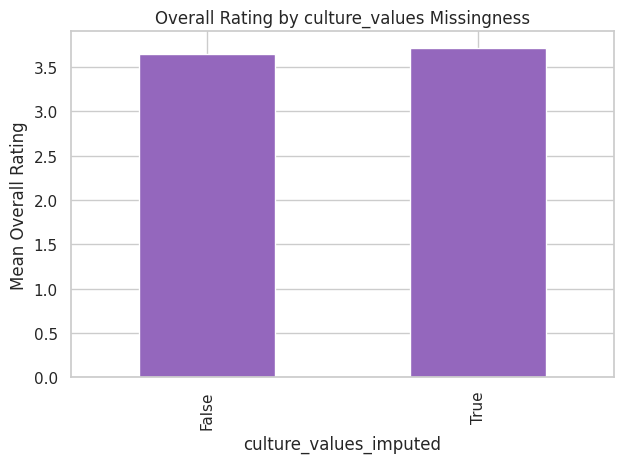

In [10]:
missing_mask = df['culture_values_imputed'] if 'culture_values_imputed' in df.columns else df['culture_values'].isna()
bias = df.groupby(missing_mask)['overall_rating'].mean()
bias.plot(kind='bar', color='#9467BD')
plt.title('Overall Rating by culture_values Missingness')
plt.xlabel('culture_values_imputed')
plt.ylabel('Mean Overall Rating')
plt.tight_layout()
bias


## Rendered Plots (Static)
Notebook execution via Jupyter kernel is restricted in this environment, so plots are rendered to `artifacts/eda/`.
Below are the generated images.

### Missingness (Top 12)
![](artifacts/eda/missingness_top12.png)


### Top Correlations
![](artifacts/eda/corr_top10.png)


### MWQ Over Time
![](artifacts/eda/mwq_over_time.png)


### Top 10 Firms
![](artifacts/eda/top10_firms.png)


### Bottom 10 Firms
![](artifacts/eda/bottom10_firms.png)


### Missingness Bias
![](artifacts/eda/missingness_bias.png)
